# BARRA API Demo

In [1]:
from shelterbelts.apis.barra_daily import barra_daily

## Default Parameters
The default location is a ~2km x 2km region near Milgadara, NSW, Australia for 2020-2021. This should take about 20 secs to load.

In [2]:
%%time
ds = barra_daily()
ds

Saved: ./TEST_barra_daily.nc
Saved ./TEST_barra_daily.png
CPU times: user 3.05 s, sys: 1.19 s, total: 4.24 s
Wall time: 24.6 s


<xarray.Dataset> Size: 18kB
Dimensions:    (time: 731, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2020-01-01T12:00:00 ... 2021-12-31T1...
  * longitude  (longitude) float64 8B 148.5
  * latitude   (latitude) float64 8B -34.37
Data variables:
    uas        (time, latitude, longitude) float64 6kB -0.1562 -1.3 ... -1.956
    vas        (time, latitude, longitude) float64 6kB 2.32 1.606 ... -0.6328
Attributes: (12/61)
    axiom_version:                   0.1.0
    axiom_schemas_version:           0.1.0
    axiom_schema:                    cordex-1D.json
    productive_version:              8935ea8
    variable_version:                v20240516
    Conventions:                     CF-1.10, ACDD-1.3
    ...                              ...
    date_metadata_modified:          2024-10-11T00:17:33Z
    history:                         Fri Apr 19 15:37:45 2024: /g/data/access...
    references:                      https://doi.org/10.25914/1x6g-2v48
    license:                         https://doi.org/10.25914/1x6g-2v48
    acknowledgement:                 The production of BARRA2 was supported w...
    DODS_EXTRA.Unlimited_Dimension:  time

## Visualising the Results
The default output includes a wind rose visualisation showing wind speed distribution by direction.

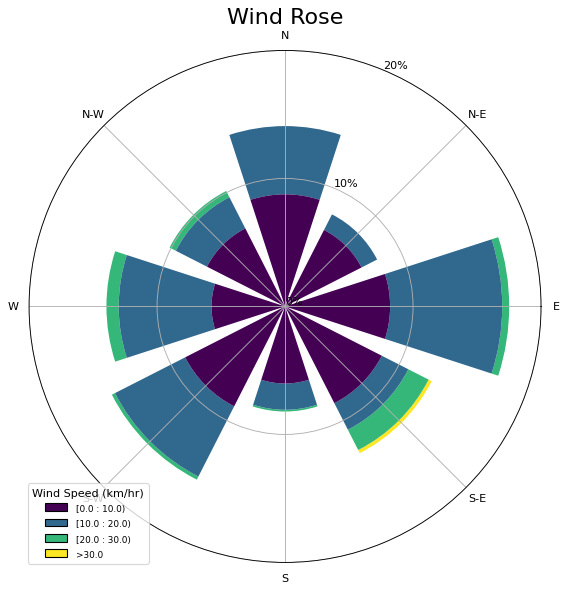

In [3]:
from shelterbelts.apis.barra_daily import wind_rose

wind_rose(ds)

## Wind Statistics
You can also get the dominant wind direction above a certain threshold and wind statistics.

In [4]:
from shelterbelts.apis.barra_daily import dominant_wind_direction, wind_dataframe

direction, df_counts = dominant_wind_direction(ds, threshold_kmh=15)
print(f"Dominant wind direction (>15 km/h): {direction}")
print(df_counts)

Dominant wind direction (>15 km/h): E
  Direction  Count
0         N      8
1        NE      2
2         E     33
3        SE     20
4         S      4
5        SW     18
6         W     29
7        NW      5


In [5]:
df_wind, max_speed, max_direction = wind_dataframe(ds)
print("Wind speed and direction frequency (%):")
print(df_wind)
print(f"Maximum wind speed: {max_speed} km/h from {max_direction}")

Wind speed and direction frequency (%):
               N    NE     E    SE     S    SW     W    NW
0-10km/hr   8.76  6.70  8.21  8.48  6.02  8.76  5.75  6.84
10-20km/hr  5.34  1.37  8.76  2.33  2.05  6.16  7.25  2.74
20-30km/hr  0.00  0.00  0.55  1.78  0.14  0.27  0.96  0.55
30+ km/hr   0.00  0.00  0.00  0.27  0.00  0.00  0.00  0.00
Maximum wind speed: 31.65 km/h from SE


## Changing Variables
You can download different BARRA variables. The default is Eastward and Northward Near-Surface Wind, which can be combined to get wind direction and magnitude. See the full documentation for other available variables: https://geonetwork.nci.org.au/geonetwork/srv/eng/catalog.search#/metadata/f2551_3726_7908_8861

In [6]:
barra_daily(variables=["sfcWind"], plot=False) # Near surface wind speed

Saved: ./TEST_barra_daily.nc


<xarray.Dataset> Size: 12kB
Dimensions:    (time: 731, latitude: 1, longitude: 1)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2020-01-01T12:00:00 ... 2021-12-31T1...
  * latitude   (latitude) float64 8B -34.37
  * longitude  (longitude) float64 8B 148.5
Data variables:
    sfcWind    (time, latitude, longitude) float64 6kB 3.768 3.105 ... 2.492
Attributes: (12/61)
    axiom_version:                   0.1.0
    axiom_schemas_version:           0.1.0
    axiom_schema:                    cordex-1D.json
    productive_version:              8935ea8
    variable_version:                v20240516
    Conventions:                     CF-1.10, ACDD-1.3
    ...                              ...
    date_metadata_modified:          2024-10-11T00:16:20Z
    history:                         Fri Apr 19 15:38:36 2024: /g/data/access...
    references:                      https://doi.org/10.25914/1x6g-2v48
    license:                         https://doi.org/10.25914/1x6g-2v48
    acknowledgement:                 The production of BARRA2 was supported w...
    DODS_EXTRA.Unlimited_Dimension:  time

## Changing Time Period
Adjust the start_year and end_year parameters to download data for different time periods. These years are inclusive, so using the same value gets one year of data.

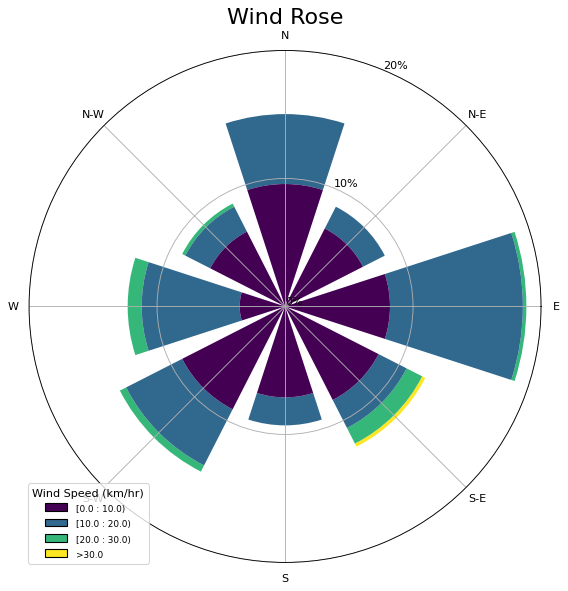

CPU times: user 1.06 s, sys: 183 ms, total: 1.24 s
Wall time: 3.22 s


In [7]:
%%time
ds_longer = barra_daily(start_year="2020", end_year="2020", save_netcdf=False, plot=False)
wind_rose(ds_longer)

## Changing Location
Use the lat and lon arguments to download data for a different location. Here is an example of ANU in Canberra.

Saved: ./TEST_barra_daily.nc
Saved ./TEST_barra_daily.png


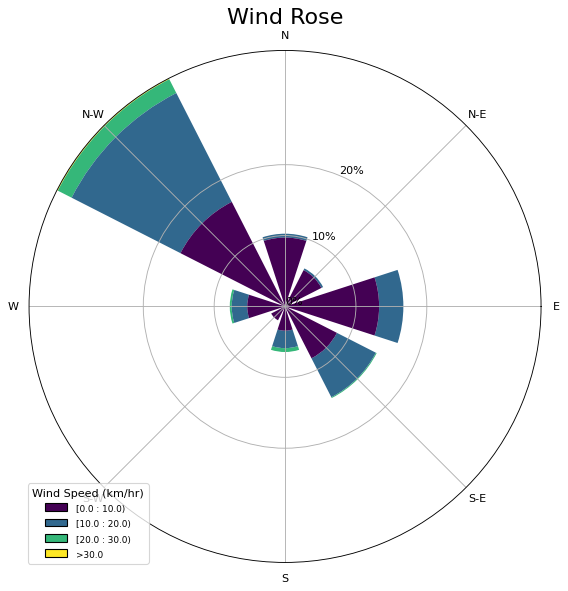

In [8]:
ds_canberra = barra_daily(lat=-35.287, lon=149.117)
wind_rose(ds_canberra)

## Changing Output Directory
Specify a custom output directory for the saved files.

In [9]:
import os
outdir = "outdir"
os.makedirs(outdir, exist_ok=True)
ds = barra_daily(outdir=outdir)

Saved: outdir/TEST_barra_daily.nc
Saved outdir/TEST_barra_daily.png


## Changing Filename Prefix
Choose a stub to be used as the prefix for output filenames.

In [10]:
ds = barra_daily(stub="DEMO")

Saved: ./DEMO_barra_daily.nc
Saved ./DEMO_barra_daily.png


## Disabling NetCDF Output
Set `save_netcdf=False` to skip saving the NetCDF file. 
Useful when running within a larger pipeline.

In [11]:
ds = barra_daily(save_netcdf=False)

Saved ./TEST_barra_daily.png


## Disabling Visualization
Set `plot=False` to skip generating and saving the wind rose PNG visualisation. 
This can be used in combination with `save_netcdf=False` to avoid any outputs.

In [12]:
ds = barra_daily(plot=False)

Saved: ./TEST_barra_daily.nc


## Using Different Temporal Resolutions
You can request data at different temporal resolutions: '20min', '1hr', 'day', or 'mon'.
Monthly data is much faster to download.

In [13]:
%%time
ds_monthly = barra_daily(temporal='mon', save_netcdf=False, plot=False)
print(f"Monthly data shape: {ds_monthly.dims}")
print(f"Daily data shape: {ds.dims}")

Monthly data shape: FrozenMappingWarningOnValuesAccess({'time': 24, 'latitude': 1, 'longitude': 1})
Daily data shape: FrozenMappingWarningOnValuesAccess({'time': 731, 'latitude': 1, 'longitude': 1})
CPU times: user 1.38 s, sys: 305 ms, total: 1.69 s
Wall time: 7.04 s


## Command Line Interface
You can also use the function from the command line with the same defaults and parameters.

In [14]:
!python -m shelterbelts.apis.barra_daily --help

usage: barra_daily.py [-h] [--lat LAT] [--lon LON] [--buffer BUFFER]
                      [--start_year START_YEAR] [--end_year END_YEAR]
                      [--outdir OUTDIR] [--stub STUB] [--no-save-netcdf]
                      [--no-plot] [--gdata] [--temporal TEMPORAL]

options:
  -h, --help            show this help message and exit
  --lat LAT             Latitude in EPSG:4326 (default: -34.389)
  --lon LON             Longitude in EPSG:4326 (default: 148.469)
  --buffer BUFFER       Buffer in each direction in degrees (default is 0.01,
                        or about 2kmx2km)
  --start_year START_YEAR
                        Inclusive, and the minimum start year is 1889. Setting
                        the start and end year to the same value will get all
                        data for that year.
  --end_year END_YEAR   Specifying a larger end_year than available will
                        automatically give data up to the most recent date
                        (curre

In [15]:
%%time
!python -m shelterbelts.apis.barra_daily

Saved: ./TEST_barra_daily.nc
Saved ./TEST_barra_daily.png
CPU times: user 186 ms, sys: 46.4 ms, total: 232 ms
Wall time: 10.2 s


In [16]:
!python -m shelterbelts.apis.barra_daily --lat -35.287 --lon 149.117 --start_year 2020 --end_year 2020 --stub command_line

Saved: ./command_line_barra_daily.nc
Saved ./command_line_barra_daily.png


### Cleanup
Remove the output files created by this notebook

In [18]:
# !rm *.nc
# !rm *.png